<a href="https://colab.research.google.com/github/Vishnu14git/DocSpot/blob/main/EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('/content/housing_prices_regression.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   num_bedrooms   238 non-null    float64
 1   year_built     241 non-null    float64
 2   zipcode_dup    230 non-null    float64
 3   zipcode        230 non-null    float64
 4   size_sqft      237 non-null    object 
 5   has_garage     237 non-null    object 
 6   id             230 non-null    object 
 7   has_garden     232 non-null    object 
 8   num_bathrooms  221 non-null    float64
 9   sale_price     238 non-null    float64
dtypes: float64(6), object(4)
memory usage: 20.4+ KB


In [130]:
df.head()



,num_bedrooms,year_built,zipcode_dup,zipcode,size_sqft,has_garage,id,has_garden,num_bathrooms,sale_price
0,2.0,2021.0,110002.0,110002.0,1075,Ys,H20000,NaN,3.0,NaN
1,3.0,1954.0,560001.0,560001.0,1482,Ye,H20001,o,1.5,293483.53
2,2.0,1991.0,560002.0,560002.0,1689,No,H20002,No,2.5,179736.91
3,3.0,1956.0,NaN,NaN,1415,Yes,H20003,es,NaN,462700.04
4,NaN,1991.0,560001.0,560001.0,1765,No,H20004,NO,1.0,272214.40


In [131]:
print(df.isnull().sum())

num_bedrooms     22
year_built       19
zipcode_dup      30
zipcode          30
size_sqft        23
has_garage       23
id               30
has_garden       28
num_bathrooms    39
sale_price       22
dtype: int64


In [132]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
255,True
256,True
257,True
258,True


In [133]:
df.drop_duplicates(ignore_index=True,inplace=True)
df

,num_bedrooms,year_built,zipcode_dup,zipcode,size_sqft,has_garage,id,has_garden,num_bathrooms,sale_price
0,2.0,2021.0,110002.0,110002.0,1075,Ys,H20000,NaN,3.0,NaN
1,3.0,1954.0,560001.0,560001.0,1482,Ye,H20001,o,1.5,293483.53
2,2.0,1991.0,560002.0,560002.0,1689,No,H20002,No,2.5,179736.91
3,3.0,1956.0,NaN,NaN,1415,Yes,H20003,es,NaN,462700.04
4,NaN,1991.0,560001.0,560001.0,1765,No,H20004,NO,1.0,272214.40
...,...,...,...,...,...,...,...,...,...,...
245,2.0,1990.0,110002.0,110002.0,1013,N,H20245,Ye,2.0,248078.69
246,5.0,1982.0,110001.0,110001.0,1907,No,H20246,o,1.0,708685.96
247,2.0,1965.0,110001.0,110001.0,NaN,YES,H20247,No,NaN,487109.41
248,2.0,1972.0,560002.0,560002.0,1760,No,H20248,o,NaN,498054.37


In [134]:
df.duplicated().sum()

np.int64(0)

In [135]:
df.drop(columns=["zipcode_dup"],axis=1,inplace=True)
df

,num_bedrooms,year_built,zipcode,size_sqft,has_garage,id,has_garden,num_bathrooms,sale_price
0,2.0,2021.0,110002.0,1075,Ys,H20000,NaN,3.0,NaN
1,3.0,1954.0,560001.0,1482,Ye,H20001,o,1.5,293483.53
2,2.0,1991.0,560002.0,1689,No,H20002,No,2.5,179736.91
3,3.0,1956.0,NaN,1415,Yes,H20003,es,NaN,462700.04
4,NaN,1991.0,560001.0,1765,No,H20004,NO,1.0,272214.40
...,...,...,...,...,...,...,...,...,...
245,2.0,1990.0,110002.0,1013,N,H20245,Ye,2.0,248078.69
246,5.0,1982.0,110001.0,1907,No,H20246,o,1.0,708685.96
247,2.0,1965.0,110001.0,NaN,YES,H20247,No,NaN,487109.41
248,2.0,1972.0,560002.0,1760,No,H20248,o,NaN,498054.37


In [136]:
df["num_bedrooms"].unique()

array([ 2.,  3., nan,  5.,  4.,  1.])

In [137]:
# Fill missing values in 'num_bedrooms' with the most common value
df["num_bedrooms"].fillna(df["num_bedrooms"].mode()[0], inplace=True)
df

/tmp/ipython-input-821452998.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["num_bedrooms"].fillna(df["num_bedrooms"].mode()[0], inplace=True)


,num_bedrooms,year_built,zipcode,size_sqft,has_garage,id,has_garden,num_bathrooms,sale_price
0,2.0,2021.0,110002.0,1075,Ys,H20000,NaN,3.0,NaN
1,3.0,1954.0,560001.0,1482,Ye,H20001,o,1.5,293483.53
2,2.0,1991.0,560002.0,1689,No,H20002,No,2.5,179736.91
3,3.0,1956.0,NaN,1415,Yes,H20003,es,NaN,462700.04
4,3.0,1991.0,560001.0,1765,No,H20004,NO,1.0,272214.40
...,...,...,...,...,...,...,...,...,...
245,2.0,1990.0,110002.0,1013,N,H20245,Ye,2.0,248078.69
246,5.0,1982.0,110001.0,1907,No,H20246,o,1.0,708685.96
247,2.0,1965.0,110001.0,NaN,YES,H20247,No,NaN,487109.41
248,2.0,1972.0,560002.0,1760,No,H20248,o,NaN,498054.37


In [138]:
df["num_bedrooms"].unique()

array([2., 3., 5., 4., 1.])

In [139]:
df["num_bedrooms"].isnull().sum()

np.int64(0)

In [140]:
df["year_built"].unique()

array([2021., 1954., 1991., 1956., 1985., 1976., 2007., 1995., 2015.,
       1974., 1950., 2001., 2003., 2016., 1955., 2019., 2002.,   nan,
       1951., 1971., 1986., 1969., 1973., 2014., 2004., 2013., 1994.,
       1975., 1984., 1977., 1965., 2008., 1964., 1960., 2017., 1992.,
       2018., 1962., 1959., 1990., 1999., 2020., 1988., 1952., 1998.,
       1982., 1997., 1981., 2009., 2005., 1979., 1967., 1970., 1993.,
       1996., 1978., 1966., 1980., 1963., 2000., 1953., 1961., 1958.,
       2011., 2006., 1957., 2010., 1983., 1968., 1989., 1972.])

In [141]:
df["year_built"].fillna(df["year_built"].mode()[0], inplace=True)
df

/tmp/ipython-input-1730085049.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["year_built"].fillna(df["year_built"].mode()[0], inplace=True)


,num_bedrooms,year_built,zipcode,size_sqft,has_garage,id,has_garden,num_bathrooms,sale_price
0,2.0,2021.0,110002.0,1075,Ys,H20000,NaN,3.0,NaN
1,3.0,1954.0,560001.0,1482,Ye,H20001,o,1.5,293483.53
2,2.0,1991.0,560002.0,1689,No,H20002,No,2.5,179736.91
3,3.0,1956.0,NaN,1415,Yes,H20003,es,NaN,462700.04
4,3.0,1991.0,560001.0,1765,No,H20004,NO,1.0,272214.40
...,...,...,...,...,...,...,...,...,...
245,2.0,1990.0,110002.0,1013,N,H20245,Ye,2.0,248078.69
246,5.0,1982.0,110001.0,1907,No,H20246,o,1.0,708685.96
247,2.0,1965.0,110001.0,NaN,YES,H20247,No,NaN,487109.41
248,2.0,1972.0,560002.0,1760,No,H20248,o,NaN,498054.37


In [142]:
df["year_built"].isnull().sum()


np.int64(0)

In [143]:
df["zipcode"].unique()

array([110002., 560001., 560002.,     nan, 110001., 110003.])

In [144]:
df["zipcode"].fillna(df["zipcode"].mode()[0], inplace=True)
df

/tmp/ipython-input-3406646918.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["zipcode"].fillna(df["zipcode"].mode()[0], inplace=True)


,num_bedrooms,year_built,zipcode,size_sqft,has_garage,id,has_garden,num_bathrooms,sale_price
0,2.0,2021.0,110002.0,1075,Ys,H20000,NaN,3.0,NaN
1,3.0,1954.0,560001.0,1482,Ye,H20001,o,1.5,293483.53
2,2.0,1991.0,560002.0,1689,No,H20002,No,2.5,179736.91
3,3.0,1956.0,110001.0,1415,Yes,H20003,es,NaN,462700.04
4,3.0,1991.0,560001.0,1765,No,H20004,NO,1.0,272214.40
...,...,...,...,...,...,...,...,...,...
245,2.0,1990.0,110002.0,1013,N,H20245,Ye,2.0,248078.69
246,5.0,1982.0,110001.0,1907,No,H20246,o,1.0,708685.96
247,2.0,1965.0,110001.0,NaN,YES,H20247,No,NaN,487109.41
248,2.0,1972.0,560002.0,1760,No,H20248,o,NaN,498054.37


In [145]:
df["zipcode"].isnull().sum()


np.int64(0)

In [146]:
df["size_sqft"].unique()

array(['1075', '1482', '1689', '1415', '1765', '1177', '1901', '1549',
       '2118', '2466', '1312', '1328', '1402', '1738', '2030', '1239',
       '1652', '1446', '1747', '2104', '1404', '832', '1798', '1167',
       'unknown', '1815', '1619', '1459', '1270', '340', '1779', '1399',
       '2105', nan, '1284', '1927', '1960', '1412', '1977', '1278',
       '1729', '1749', '1367', '1937', '1450', '1272', '2276', '1203',
       '2017', '1046', '1695', '2148', '1238', '1128', '1453', '2166',
       '1146', '465', '1524', '1880', '1094', '1839', '1086', '1441',
       '1801', '1573', '1986', '1690', '1212', '2107', '1763', '756',
       '1846', '1271', '1579', '1903', '1280', '842', '2102', '1966',
       '1465', '1841', '1352', '1539', '1442', '1368', '1644', '1017',
       '1626', '1033', '1708', '749', '1852', '1735', '1466', '1633',
       '1568', '824', '1577', '1353', '1218', '2494', '2001', '1040',
       '2083', '902', '1531', '1550', '990', '1946', '2103', '1400',
       '2501', 

In [147]:
df["size_sqft"].replace("unknown", np.nan, inplace=True)
df["size_sqft"] = pd.to_numeric(df["size_sqft"], errors="coerce")
df["size_sqft"].fillna(df["size_sqft"].median(), inplace=True)
df

/tmp/ipython-input-2763446111.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["size_sqft"].replace("unknown", np.nan, inplace=True)
/tmp/ipython-input-2763446111.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

,num_bedrooms,year_built,zipcode,size_sqft,has_garage,id,has_garden,num_bathrooms,sale_price
0,2.0,2021.0,110002.0,1075.0,Ys,H20000,NaN,3.0,NaN
1,3.0,1954.0,560001.0,1482.0,Ye,H20001,o,1.5,293483.53
2,2.0,1991.0,560002.0,1689.0,No,H20002,No,2.5,179736.91
3,3.0,1956.0,110001.0,1415.0,Yes,H20003,es,NaN,462700.04
4,3.0,1991.0,560001.0,1765.0,No,H20004,NO,1.0,272214.40
...,...,...,...,...,...,...,...,...,...
245,2.0,1990.0,110002.0,1013.0,N,H20245,Ye,2.0,248078.69
246,5.0,1982.0,110001.0,1907.0,No,H20246,o,1.0,708685.96
247,2.0,1965.0,110001.0,1513.0,YES,H20247,No,NaN,487109.41
248,2.0,1972.0,560002.0,1760.0,No,H20248,o,NaN,498054.37


In [148]:
df["size_sqft"].unique()

array([ 1075.,  1482.,  1689.,  1415.,  1765.,  1177.,  1901.,  1549.,
        2118.,  2466.,  1312.,  1328.,  1402.,  1738.,  2030.,  1239.,
        1652.,  1446.,  1747.,  2104.,  1404.,   832.,  1798.,  1167.,
        1513.,  1815.,  1619.,  1459.,  1270.,   340.,  1779.,  1399.,
        2105.,  1284.,  1927.,  1960.,  1412.,  1977.,  1278.,  1729.,
        1749.,  1367.,  1937.,  1450.,  1272.,  2276.,  1203.,  2017.,
        1046.,  1695.,  2148.,  1238.,  1128.,  1453.,  2166.,  1146.,
         465.,  1524.,  1880.,  1094.,  1839.,  1086.,  1441.,  1801.,
        1573.,  1986.,  1690.,  1212.,  2107.,  1763.,   756.,  1846.,
        1271.,  1579.,  1903.,  1280.,   842.,  2102.,  1966.,  1465.,
        1841.,  1352.,  1539.,  1442.,  1368.,  1644.,  1017.,  1626.,
        1033.,  1708.,   749.,  1852.,  1735.,  1466.,  1633.,  1568.,
         824.,  1577.,  1353.,  1218.,  2494.,  2001.,  1040.,  2083.,
         902.,  1531.,  1550.,   990.,  1946.,  2103.,  1400.,  2501.,
      

In [149]:
df["size_sqft"].replace("unknown", np.nan, inplace=True)
df["size_sqft"] = pd.to_numeric(df["size_sqft"], errors="coerce")
df["size_sqft"].fillna(df["size_sqft"].median(), inplace=True)
df

/tmp/ipython-input-2763446111.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["size_sqft"].replace("unknown", np.nan, inplace=True)
/tmp/ipython-input-2763446111.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

,num_bedrooms,year_built,zipcode,size_sqft,has_garage,id,has_garden,num_bathrooms,sale_price
0,2.0,2021.0,110002.0,1075.0,Ys,H20000,NaN,3.0,NaN
1,3.0,1954.0,560001.0,1482.0,Ye,H20001,o,1.5,293483.53
2,2.0,1991.0,560002.0,1689.0,No,H20002,No,2.5,179736.91
3,3.0,1956.0,110001.0,1415.0,Yes,H20003,es,NaN,462700.04
4,3.0,1991.0,560001.0,1765.0,No,H20004,NO,1.0,272214.40
...,...,...,...,...,...,...,...,...,...
245,2.0,1990.0,110002.0,1013.0,N,H20245,Ye,2.0,248078.69
246,5.0,1982.0,110001.0,1907.0,No,H20246,o,1.0,708685.96
247,2.0,1965.0,110001.0,1513.0,YES,H20247,No,NaN,487109.41
248,2.0,1972.0,560002.0,1760.0,No,H20248,o,NaN,498054.37


In [150]:
df["size_sqft"].replace("unknown", np.nan, inplace=True)
df["size_sqft"] = pd.to_numeric(df["size_sqft"], errors="coerce")
df["size_sqft"].fillna(df["size_sqft"].median(), inplace=True)
df


/tmp/ipython-input-346199552.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["size_sqft"].replace("unknown", np.nan, inplace=True)
/tmp/ipython-input-346199552.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

,num_bedrooms,year_built,zipcode,size_sqft,has_garage,id,has_garden,num_bathrooms,sale_price
0,2.0,2021.0,110002.0,1075.0,Ys,H20000,NaN,3.0,NaN
1,3.0,1954.0,560001.0,1482.0,Ye,H20001,o,1.5,293483.53
2,2.0,1991.0,560002.0,1689.0,No,H20002,No,2.5,179736.91
3,3.0,1956.0,110001.0,1415.0,Yes,H20003,es,NaN,462700.04
4,3.0,1991.0,560001.0,1765.0,No,H20004,NO,1.0,272214.40
...,...,...,...,...,...,...,...,...,...
245,2.0,1990.0,110002.0,1013.0,N,H20245,Ye,2.0,248078.69
246,5.0,1982.0,110001.0,1907.0,No,H20246,o,1.0,708685.96
247,2.0,1965.0,110001.0,1513.0,YES,H20247,No,NaN,487109.41
248,2.0,1972.0,560002.0,1760.0,No,H20248,o,NaN,498054.37


In [151]:
df["has_garage"].unique()

array(['Ys', 'Ye', 'No', 'Yes', 'N', nan, 'YES', 'o', 'es', 'NO'],
      dtype=object)

In [152]:
df["has_garage"].replace({'YES': 'Yes','Ye': 'Yes','Ys': 'Yes','es': 'Yes','N': 'No','NO': 'No','o': 'No'}, inplace=True)
df["has_garage"].fillna(df["has_garage"].mode()[0], inplace=True)
df

/tmp/ipython-input-1768266891.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["has_garage"].replace({'YES': 'Yes','Ye': 'Yes','Ys': 'Yes','es': 'Yes','N': 'No','NO': 'No','o': 'No'}, inplace=True)


,num_bedrooms,year_built,zipcode,size_sqft,has_garage,id,has_garden,num_bathrooms,sale_price
0,2.0,2021.0,110002.0,1075.0,Yes,H20000,NaN,3.0,NaN
1,3.0,1954.0,560001.0,1482.0,Yes,H20001,o,1.5,293483.53
2,2.0,1991.0,560002.0,1689.0,No,H20002,No,2.5,179736.91
3,3.0,1956.0,110001.0,1415.0,Yes,H20003,es,NaN,462700.04
4,3.0,1991.0,560001.0,1765.0,No,H20004,NO,1.0,272214.40
...,...,...,...,...,...,...,...,...,...
245,2.0,1990.0,110002.0,1013.0,No,H20245,Ye,2.0,248078.69
246,5.0,1982.0,110001.0,1907.0,No,H20246,o,1.0,708685.96
247,2.0,1965.0,110001.0,1513.0,Yes,H20247,No,NaN,487109.41
248,2.0,1972.0,560002.0,1760.0,No,H20248,o,NaN,498054.37


In [153]:
df["has_garage"].unique()

array(['Yes', 'No'], dtype=object)

In [154]:

df["id"].unique()

array(['H20000', 'H20001', 'H20002', 'H20003', 'H20004', 'H20005',
       'H20006', 'H20007', 'H20008', 'H20009', 'H20010', 'H20011',
       'H20012', 'H20013', 'H20014', nan, 'H20016', 'H20017', 'H20018',
       'H20019', 'H20021', 'H20022', 'H20024', 'H20025', 'H20026',
       'H20027', 'H20028', 'H20029', 'H20030', 'H20031', 'H20032',
       'H20033', 'H20034', 'H20035', 'H20036', 'H20037', 'H20038',
       'H20040', 'H20041', 'H20042', 'H20044', 'H20045', 'H20046',
       'H20047', 'H20048', 'H20050', 'H20051', 'H20052', 'H20053',
       'H20054', 'H20055', 'H20056', 'H20057', 'H20058', 'H20059',
       'H20060', 'H20062', 'H20063', 'H20064', 'H20065', 'H20066',
       'H20068', 'H20069', 'H20070', 'H20072', 'H20073', 'H20074',
       'H20075', 'H20076', 'H20077', 'H20078', 'H20079', 'H20080',
       'H20081', 'H20082', 'H20083', 'H20084', 'H20085', 'H20086',
       'H20087', 'H20088', 'H20089', 'H20091', 'H20092', 'H20093',
       'H20094', 'H20095', 'H20096', 'H20098', 'H20099', 

In [155]:

# Drop rows where 'id' is NaN
df.dropna(subset=["id"], inplace=True)
df

,num_bedrooms,year_built,zipcode,size_sqft,has_garage,id,has_garden,num_bathrooms,sale_price
0,2.0,2021.0,110002.0,1075.0,Yes,H20000,NaN,3.0,NaN
1,3.0,1954.0,560001.0,1482.0,Yes,H20001,o,1.5,293483.53
2,2.0,1991.0,560002.0,1689.0,No,H20002,No,2.5,179736.91
3,3.0,1956.0,110001.0,1415.0,Yes,H20003,es,NaN,462700.04
4,3.0,1991.0,560001.0,1765.0,No,H20004,NO,1.0,272214.40
...,...,...,...,...,...,...,...,...,...
245,2.0,1990.0,110002.0,1013.0,No,H20245,Ye,2.0,248078.69
246,5.0,1982.0,110001.0,1907.0,No,H20246,o,1.0,708685.96
247,2.0,1965.0,110001.0,1513.0,Yes,H20247,No,NaN,487109.41
248,2.0,1972.0,560002.0,1760.0,No,H20248,o,NaN,498054.37


In [156]:
df["id"].unique()

array(['H20000', 'H20001', 'H20002', 'H20003', 'H20004', 'H20005',
       'H20006', 'H20007', 'H20008', 'H20009', 'H20010', 'H20011',
       'H20012', 'H20013', 'H20014', 'H20016', 'H20017', 'H20018',
       'H20019', 'H20021', 'H20022', 'H20024', 'H20025', 'H20026',
       'H20027', 'H20028', 'H20029', 'H20030', 'H20031', 'H20032',
       'H20033', 'H20034', 'H20035', 'H20036', 'H20037', 'H20038',
       'H20040', 'H20041', 'H20042', 'H20044', 'H20045', 'H20046',
       'H20047', 'H20048', 'H20050', 'H20051', 'H20052', 'H20053',
       'H20054', 'H20055', 'H20056', 'H20057', 'H20058', 'H20059',
       'H20060', 'H20062', 'H20063', 'H20064', 'H20065', 'H20066',
       'H20068', 'H20069', 'H20070', 'H20072', 'H20073', 'H20074',
       'H20075', 'H20076', 'H20077', 'H20078', 'H20079', 'H20080',
       'H20081', 'H20082', 'H20083', 'H20084', 'H20085', 'H20086',
       'H20087', 'H20088', 'H20089', 'H20091', 'H20092', 'H20093',
       'H20094', 'H20095', 'H20096', 'H20098', 'H20099', 'H201

In [157]:

df["has_garden"].unique()

array([nan, 'o', 'No', 'es', 'NO', 'Yes', 'Ye', 'N', 'Ys', 'YES'],
      dtype=object)

In [158]:
df["has_garden"].replace({'Yes': 'Yes', 'Ye': 'Yes', 'Ys': 'Yes', 'YES': 'Yes', 'es': 'Yes','No': 'No', 'N': 'No', 'NO': 'No', 'o': 'No' },inplace=True)
df["has_garden"].fillna(df["has_garden"].mode()[0], inplace=True)
df

/tmp/ipython-input-1384579504.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["has_garden"].replace({'Yes': 'Yes', 'Ye': 'Yes', 'Ys': 'Yes', 'YES': 'Yes', 'es': 'Yes','No': 'No', 'N': 'No', 'NO': 'No', 'o': 'No' },inplace=True)


,num_bedrooms,year_built,zipcode,size_sqft,has_garage,id,has_garden,num_bathrooms,sale_price
0,2.0,2021.0,110002.0,1075.0,Yes,H20000,No,3.0,NaN
1,3.0,1954.0,560001.0,1482.0,Yes,H20001,No,1.5,293483.53
2,2.0,1991.0,560002.0,1689.0,No,H20002,No,2.5,179736.91
3,3.0,1956.0,110001.0,1415.0,Yes,H20003,Yes,NaN,462700.04
4,3.0,1991.0,560001.0,1765.0,No,H20004,No,1.0,272214.40
...,...,...,...,...,...,...,...,...,...
245,2.0,1990.0,110002.0,1013.0,No,H20245,Yes,2.0,248078.69
246,5.0,1982.0,110001.0,1907.0,No,H20246,No,1.0,708685.96
247,2.0,1965.0,110001.0,1513.0,Yes,H20247,No,NaN,487109.41
248,2.0,1972.0,560002.0,1760.0,No,H20248,No,NaN,498054.37


In [159]:
df["has_garden"].unique()

array(['No', 'Yes'], dtype=object)

In [160]:
df["num_bathrooms"].unique()

array([3. , 1.5, 2.5, nan, 1. , 2. ])

In [161]:
df["num_bathrooms"] = df["num_bathrooms"].round()
df["num_bathrooms"].fillna(df["num_bathrooms"].median(), inplace=True)
df

/tmp/ipython-input-2858557140.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["num_bathrooms"].fillna(df["num_bathrooms"].median(), inplace=True)


,num_bedrooms,year_built,zipcode,size_sqft,has_garage,id,has_garden,num_bathrooms,sale_price
0,2.0,2021.0,110002.0,1075.0,Yes,H20000,No,3.0,NaN
1,3.0,1954.0,560001.0,1482.0,Yes,H20001,No,2.0,293483.53
2,2.0,1991.0,560002.0,1689.0,No,H20002,No,2.0,179736.91
3,3.0,1956.0,110001.0,1415.0,Yes,H20003,Yes,2.0,462700.04
4,3.0,1991.0,560001.0,1765.0,No,H20004,No,1.0,272214.40
...,...,...,...,...,...,...,...,...,...
245,2.0,1990.0,110002.0,1013.0,No,H20245,Yes,2.0,248078.69
246,5.0,1982.0,110001.0,1907.0,No,H20246,No,1.0,708685.96
247,2.0,1965.0,110001.0,1513.0,Yes,H20247,No,2.0,487109.41
248,2.0,1972.0,560002.0,1760.0,No,H20248,No,2.0,498054.37


In [162]:
df["num_bathrooms"].unique()

array([3., 2., 1.])

In [163]:
df["sale_price"].unique()

array([      nan, 293483.53, 179736.91, 462700.04, 272214.4 ,  94965.59,
       557454.69, 307194.16,  89077.02, 358249.24, 370598.3 , 272870.62,
       555601.45, 783768.06, 327503.47, 235789.19, 102686.06, 126793.55,
       617082.28, 723240.42, 541909.85, 111019.06, 547455.22, 519279.5 ,
       650438.22, 665441.47, 348881.27, 567355.58, 236552.78, 799488.94,
       165007.37,  37788.11, 627421.66, 374023.43, 374575.19, 738118.88,
       269619.95, 190974.76, 683331.3 , 727634.68, 514656.26, 227824.  ,
       646618.07, 516734.27,  76283.59, 735269.92, 503897.59, 178372.14,
       496917.31, 551646.78, 582938.34, 477719.54, 759782.58,  71346.75,
       111809.2 , 561431.72, 527108.82, 421433.73, 793710.48, 234903.13,
       671557.58, 358628.59, 529526.06, 589996.72, 517990.65, 138190.62,
       462307.55, 683763.69, 371607.23, 737435.42, 369088.15, 643139.98,
       478962.12, 432486.28,  48165.82, 348574.33, 260421.28, 606041.36,
       188019.47, 175929.66, 126724.02, 269475.39, 

In [164]:
df["sale_price"] = df["sale_price"].bfill()
df


,num_bedrooms,year_built,zipcode,size_sqft,has_garage,id,has_garden,num_bathrooms,sale_price
0,2.0,2021.0,110002.0,1075.0,Yes,H20000,No,3.0,293483.53
1,3.0,1954.0,560001.0,1482.0,Yes,H20001,No,2.0,293483.53
2,2.0,1991.0,560002.0,1689.0,No,H20002,No,2.0,179736.91
3,3.0,1956.0,110001.0,1415.0,Yes,H20003,Yes,2.0,462700.04
4,3.0,1991.0,560001.0,1765.0,No,H20004,No,1.0,272214.40
...,...,...,...,...,...,...,...,...,...
245,2.0,1990.0,110002.0,1013.0,No,H20245,Yes,2.0,248078.69
246,5.0,1982.0,110001.0,1907.0,No,H20246,No,1.0,708685.96
247,2.0,1965.0,110001.0,1513.0,Yes,H20247,No,2.0,487109.41
248,2.0,1972.0,560002.0,1760.0,No,H20248,No,2.0,498054.37


In [165]:
df["sale_price"].unique()

array([293483.53, 179736.91, 462700.04, 272214.4 ,  94965.59, 557454.69,
       307194.16,  89077.02, 358249.24, 370598.3 , 272870.62, 555601.45,
       783768.06, 327503.47, 235789.19, 102686.06, 126793.55, 617082.28,
       723240.42, 541909.85, 111019.06, 547455.22, 519279.5 , 650438.22,
       665441.47, 348881.27, 567355.58, 236552.78, 799488.94, 165007.37,
        37788.11, 627421.66, 374023.43, 374575.19, 738118.88, 269619.95,
       190974.76, 683331.3 , 727634.68, 514656.26, 227824.  , 646618.07,
       516734.27,  76283.59, 735269.92, 503897.59, 178372.14, 496917.31,
       551646.78, 582938.34, 477719.54, 759782.58,  71346.75, 111809.2 ,
       561431.72, 527108.82, 421433.73, 793710.48, 234903.13, 671557.58,
       358628.59, 529526.06, 589996.72, 517990.65, 138190.62, 462307.55,
       683763.69, 371607.23, 737435.42, 369088.15, 643139.98, 478962.12,
       432486.28,  48165.82, 348574.33, 260421.28, 606041.36, 188019.47,
       175929.66, 126724.02, 269475.39, 626694.92, 

In [166]:
df.isnull().sum()

,0
num_bedrooms,0
year_built,0
zipcode,0
size_sqft,0
has_garage,0
id,0
has_garden,0
num_bathrooms,0
sale_price,0


In [167]:
df.to_csv("cleaned_housing_prices.csv",index=False)
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 221 entries, 0 to 249
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   num_bedrooms   221 non-null    float64
 1   year_built     221 non-null    float64
 2   zipcode        221 non-null    float64
 3   size_sqft      221 non-null    float64
 4   has_garage     221 non-null    object 
 5   id             221 non-null    object 
 6   has_garden     221 non-null    object 
 7   num_bathrooms  221 non-null    float64
 8   sale_price     221 non-null    float64
dtypes: float64(6), object(3)
memory usage: 17.3+ KB


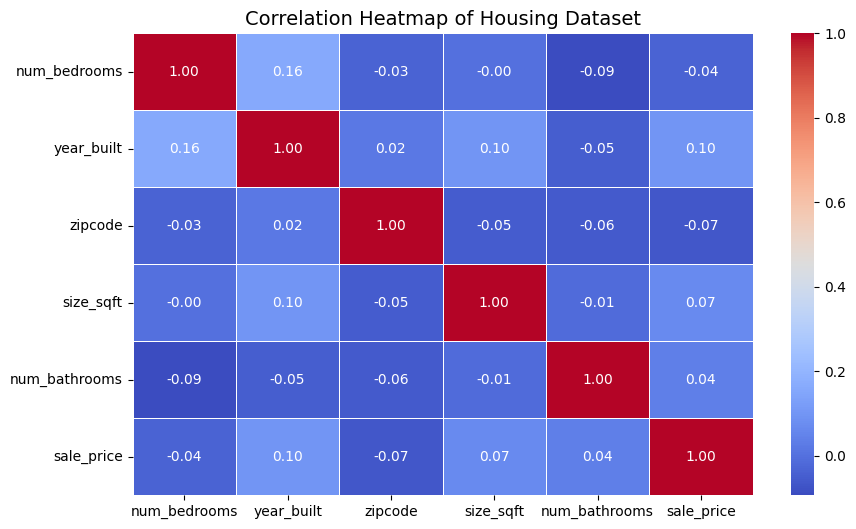

In [168]:
import seaborn as sns
df = pd.read_csv("/content/cleaned_housing_prices.csv")
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Housing Dataset", fontsize=14)
plt.show()


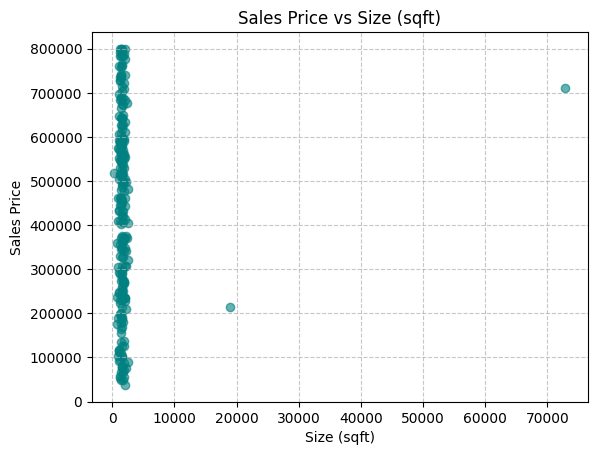

In [169]:
plt.scatter(df["size_sqft"], df["sale_price"], color="teal", alpha=0.6)
plt.title("Sales Price vs Size (sqft)")
plt.xlabel("Size (sqft)")
plt.ylabel("Sales Price")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

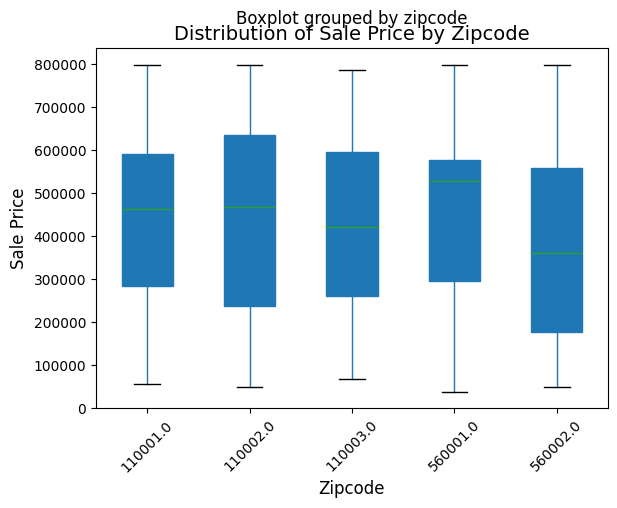

In [177]:
df.boxplot(column="sale_price", by="zipcode", grid=False, patch_artist=True)
plt.title("Distribution of Sale Price by Zipcode", fontsize=14)
plt.xlabel("Zipcode", fontsize=12)
plt.ylabel("Sale Price", fontsize=12)
plt.xticks(rotation=45)
plt.show()

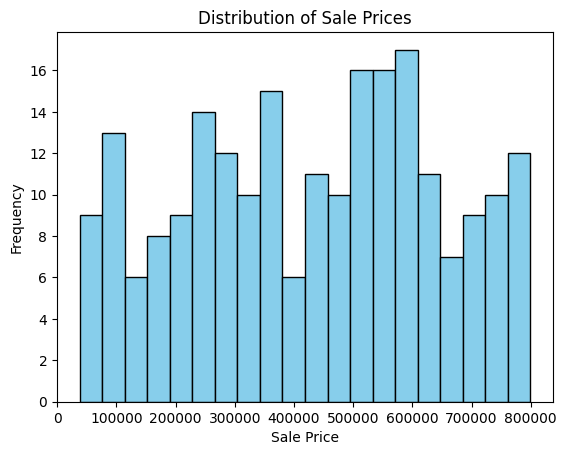

In [171]:
plt.hist(df["sale_price"], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

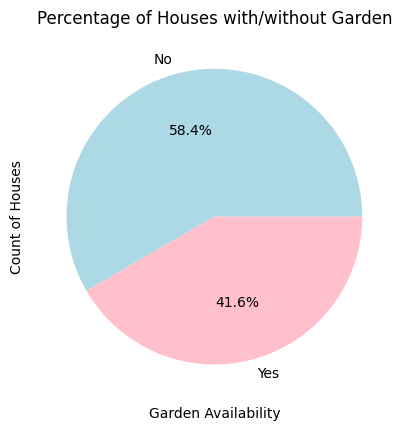

In [172]:
df["has_garden"].value_counts().plot.pie(autopct="%1.1f%%", colors=["lightblue", "pink"])
plt.title("Percentage of Houses with/without Garden")
plt.ylabel("Count of Houses")
plt.xlabel("Garden Availability")
plt.show()

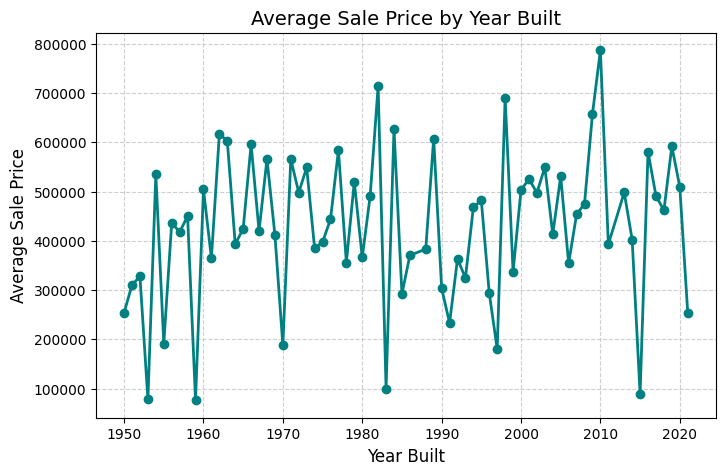

In [176]:
avg_price_by_year = df.groupby("year_built")["sale_price"].mean().sort_index()
plt.figure(figsize=(8,5))
plt.plot(avg_price_by_year.index, avg_price_by_year.values, marker='o', color='teal', linestyle='-', linewidth=2)
plt.title("Average Sale Price by Year Built", fontsize=14)
plt.xlabel("Year Built", fontsize=12)
plt.ylabel("Average Sale Price", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

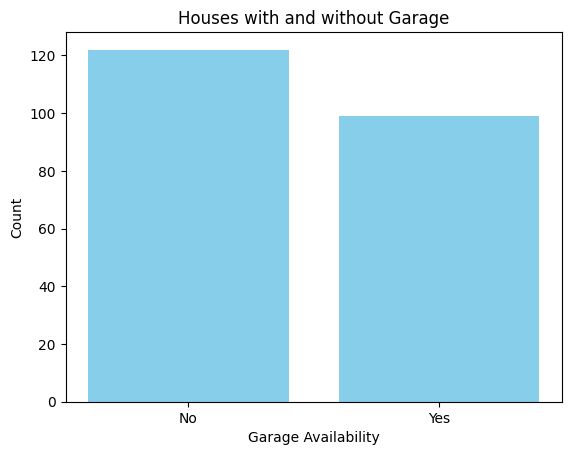

In [175]:
plt.bar(df["has_garage"].value_counts().index, df["has_garage"].value_counts().values, color="skyblue")
plt.title("Houses with and without Garage")
plt.xlabel("Garage Availability")
plt.ylabel("Count")
plt.show()

Size and number of rooms are the strongest indicators of higher prices.

Location (zipcode) greatly affects house prices — some regions are much more valuable.

Houses with garages or gardens are typically sold at higher prices.

Year built also impacts value slightly — newer constructions tend to cost more
